# Introduction

The purpose of this notebook is to show a trivial ml workflow using mlflow.

We start by generating a synthetic dataset with some noise that follows the linear model y = ax + b which a model will later try to fit.

In [1]:
import numpy as np
from pandas import DataFrame

In [2]:
SEED = 42
SAMPLES = 500

In [3]:
# Generate synthetic data following a linear model: y = ax + b
X = np.linspace(0, 10, SAMPLES)
a = 2
b = 5
y = a * X + b

# Add some noise to the data
np.random.seed(SEED)
mean = 0
std = 2
noise = np.random.normal(mean, std, X.shape)
y_noisy = y + noise

df = DataFrame({"feature": X, "target": y_noisy})

In [4]:
import matplotlib.pyplot as plt

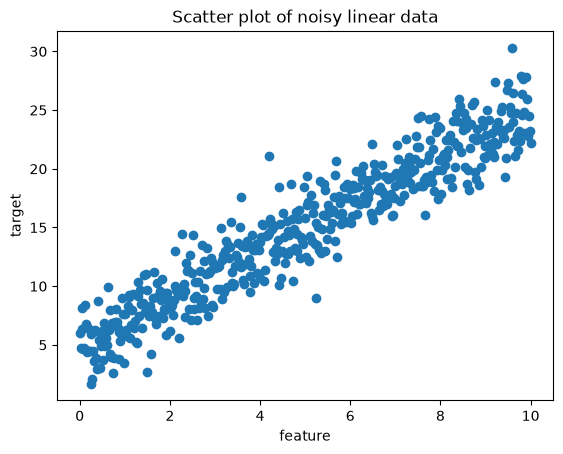

In [5]:
plt.scatter(df["feature"], df["target"])
plt.xlabel("feature")
plt.ylabel("target")
plt.title("Scatter plot of noisy linear data")
plt.show()

## Splitting datasets into train and test

We split the data into a training and a test. The training set is used for training while the test set tests the performance of the model.

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
TEST_SIZE = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    df[["feature"]], df["target"], test_size=TEST_SIZE, random_state=SEED
)

## Fitting a model
Fit a linear regression model using sklearn's LinearRegression

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['feature']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.932
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
# Get the model parameters
w_1 = model.coef_[0]
w_0 = model.intercept_
print(f"True coefficients: a = {a}, b = {b}")
print(f"Estimated coefficients: a = {w_1}, b = {w_0}")

True coefficients: a = 2, b = 5
Estimated coefficients: a = 2.014944016623748, b = 4.9318186456579856


## Evaluation

In [11]:
# Evaluate the model and compute metrics for linear regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 3.842437923472147
R^2 Score: 0.9146090103455056
Mean Absolute Error: 1.4569541074403078


## Logging
Once a model is trained, we should log everything in mlflow.

In [12]:
import mlflow

from mlflow_utils import load_config, test_server_connection


In [13]:
load_config()
test_server_connection()

Configuration loaded successfully.
MLflow connection successful!
Found 1 experiment(s)


In [14]:
# Create a signature for the model
from mlflow.models.signature import infer_signature

signature = infer_signature(X_train, model.predict(X_train))

In [15]:

mlflow.set_experiment("linear_model_demo")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1789993215417, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789993215417, lifecycle_stage='active', name='linear_model_demo', tags={}, trace_location=None, workspace='default'>

In [16]:
# Log parameters, metrics and model to MLFlow

with mlflow.start_run(run_name="demo_run_1") as run:

    # 1. Training configuration and hyperparameters
    mlflow.log_params({
        "notebook": "model_log.ipynb",
        "model_type": type(model).__name__,
        "fit_intercept": model.fit_intercept,
        "random_state": SEED,
        "train_rows": X_train.shape[0],
        "test_rows": X_test.shape[0]
    })

    # 2. Evaluation metrics
    mlflow.log_metrics({
        "mae": mae,
        "r2": r2,
        "mse": mse,
    })

    # 3. Dataset information
    mlflow.log_params({
        "dataset_version": "2026-09-21",
        "feature_count": X_train.shape[1]
    })

    # 4. Useful searchable metadata
    mlflow.set_tags({
        "team": "data-science",
        "environment": "demo",
        "task": "regression",
        "data_split": "80/20",
    })

    # 5. Model, schema, and representative input
    mlflow.sklearn.log_model(
        model,
        name="linear_regression_model",
        signature=signature,
        input_example=X_train.iloc[:2],
        # registered_model_name="linear-regression",
    )

    print("run_id:", run.info.run_id)

run_id: f48fdc9e96d742a2998e96967fb63413
🏃 View run demo_run_1 at: https://cu0089.camp.lnu.se/mlflow/#/experiments/1/runs/f48fdc9e96d742a2998e96967fb63413
🧪 View experiment at: https://cu0089.camp.lnu.se/mlflow/#/experiments/1


In [ ]:
# Download the model
model_uri = "models:/m-743e652fdd48441eadb522043e3b9cab"
model = mlflow.pyfunc.load_model(model_uri)


2026/09/21 15:42:52 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for serving_input_example.json. Retries remaining: 7
2026/09/21 15:42:52 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for python_env.yaml. Retries remaining: 7
2026/09/21 15:42:52 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for requirements.txt. Retries remaining: 7
2026/09/21 15:42:52 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for MLmodel. Retries remaining: 7
2026/09/21 15:42:53 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for input_example.json. Retries remaining: 7
2026/09/21 15:42:53 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for conda.yaml. Retries remaining: 7
2026/09/21 15:42:53 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for model.skops. Retries remaining: 7


KeyboardInterrupt: 

2026/09/21 15:43:55 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for input_example.json. Retries remaining: 6
2026/09/21 15:43:56 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for MLmodel. Retries remaining: 6
2026/09/21 15:43:56 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for requirements.txt. Retries remaining: 6
2026/09/21 15:43:56 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for conda.yaml. Retries remaining: 6
2026/09/21 15:43:57 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for serving_input_example.json. Retries remaining: 6
2026/09/21 15:43:57 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for python_env.yaml. Retries remaining: 6
2026/09/21 15:43:57 INFO mlflow.store.artifact.http_artifact_repo: Retrying 1 failed chunk(s) for model.skops. Retries remaining: 6
2026/09/21 15:45:00 INFO mlflow.store.artifact.htt